In [81]:
import numpy as np
import pandas as pd
import math
import networkx as nx

In [82]:
# a = pd.read_csv("./datasets/a280.csv")
# a = pd.read_csv("./minidatasets/minitsp.csv")
a = pd.read_csv("./datasets/xql662.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [83]:
# # distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [84]:
distance_matrix += 1

In [85]:
# MST 찾기( 프림 알고리즘 사용)
import heapq
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

mstgraph

array([[inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       [inf, inf, inf, ..., inf, inf, inf],
       ...,
       [inf, inf, inf, ..., inf,  6., inf],
       [inf, inf, inf, ...,  6., inf, 15.],
       [inf, inf, inf, ..., inf, 15., inf]])

In [86]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[1, 4, 5, 7, 12, 14, 24, 30, 31, 37, 39, 42, 44, 46, 47, 50, 52, 53, 54, 55, 66, 69, 70, 73, 74, 76, 77, 78, 80, 81, 83, 86, 88, 89, 91, 92, 94, 95, 98, 99, 102, 121, 126, 131, 134, 136, 138, 139, 142, 143, 149, 150, 151, 152, 153, 154, 155, 159, 160, 163, 167, 176, 177, 179, 183, 184, 185, 187, 191, 206, 208, 210, 219, 220, 223, 232, 233, 235, 236, 238, 240, 242, 243, 246, 247, 250, 251, 254, 255, 258, 264, 265, 266, 268, 270, 273, 274, 277, 289, 297, 299, 300, 301, 309, 311, 314, 317, 318, 319, 326, 328, 329, 341, 345, 346, 354, 356, 361, 363, 365, 366, 367, 368, 369, 375, 379, 385, 387, 391, 394, 398, 406, 409, 412, 418, 419, 420, 425, 428, 429, 434, 447, 449, 458, 460, 464, 472, 473, 477, 478, 479, 482, 485, 492, 493, 495, 501, 503, 506, 507, 514, 537, 538, 539, 546, 552, 554, 555, 556, 559, 561, 563, 567, 579, 582, 583, 586, 587, 589, 590, 593, 597, 599, 601, 602, 606, 612, 617, 620, 623, 627, 628, 629, 630, 632, 634, 639, 649, 651, 661]


In [87]:
# minimum weight perfect matching Blossom 알고리즘
graph = nx.from_numpy_array(distance_matrix)
print(graph)
mst = nx.minimum_spanning_tree(graph, weight='weight')
print(graph)
print(mst)
total_weight = mst.size(weight='weight')
print("MST 총 가중치:", total_weight)

Graph with 662 nodes and 219453 edges
Graph with 662 nodes and 219453 edges
Graph with 662 nodes and 661 edges
MST 총 가중치: 2935.8660526684375


In [88]:
oddnodeindex = [n for n, d in mst.degree() if d % 2 == 0]
oddnodeindex
oddnode = graph.copy()
oddnode.remove_nodes_from(oddnodeindex)
print(graph)

Graph with 662 nodes and 219453 edges


In [89]:
a = []
for x in oddnode.nodes(data=True):
    a.append(x[0])

a

[1,
 4,
 5,
 7,
 12,
 14,
 24,
 30,
 31,
 37,
 39,
 42,
 44,
 45,
 47,
 50,
 53,
 55,
 66,
 69,
 70,
 73,
 74,
 76,
 77,
 78,
 80,
 81,
 83,
 86,
 88,
 89,
 91,
 92,
 94,
 95,
 98,
 99,
 102,
 121,
 126,
 131,
 134,
 136,
 138,
 139,
 142,
 143,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 159,
 160,
 163,
 167,
 176,
 177,
 179,
 183,
 184,
 185,
 187,
 191,
 206,
 208,
 210,
 219,
 220,
 223,
 232,
 233,
 235,
 236,
 238,
 240,
 242,
 243,
 246,
 247,
 250,
 251,
 254,
 255,
 258,
 264,
 265,
 266,
 268,
 270,
 273,
 274,
 277,
 289,
 297,
 299,
 300,
 301,
 309,
 311,
 314,
 317,
 318,
 319,
 326,
 328,
 329,
 341,
 345,
 346,
 354,
 356,
 361,
 363,
 365,
 366,
 367,
 368,
 369,
 375,
 379,
 385,
 387,
 391,
 394,
 398,
 406,
 409,
 412,
 418,
 419,
 420,
 425,
 428,
 429,
 434,
 447,
 449,
 458,
 460,
 464,
 472,
 473,
 477,
 478,
 479,
 482,
 485,
 492,
 493,
 495,
 501,
 503,
 506,
 507,
 514,
 537,
 538,
 539,
 546,
 552,
 554,
 555,
 556,
 559,
 561,
 563,
 567,
 579,
 582,
 583

In [90]:
matching = nx.algorithms.matching.min_weight_matching( oddnode, weight='weight' )

In [91]:
print(matching)
sum =0
sum+= distance_matrix[28][20]
sum+= distance_matrix[15][4]
sum+= distance_matrix[10][7]
sum+= distance_matrix[14][9]
sum+= distance_matrix[16][18]
print(sum)

sum =0
sum+= distance_matrix[28][20]
sum+= distance_matrix[15][7]
sum+= distance_matrix[10][4]
sum+= distance_matrix[14][9]
sum+= distance_matrix[16][18]
print(sum)

{(81, 76), (243, 236), (561, 582), (579, 563), (78, 77), (634, 661), (501, 546), (250, 223), (629, 628), (102, 98), (425, 434), (242, 233), (507, 506), (627, 651), (266, 254), (311, 341), (126, 121), (329, 319), (235, 220), (477, 464), (398, 409), (155, 142), (219, 187), (143, 149), (251, 265), (482, 472), (479, 485), (74, 70), (328, 318), (86, 92), (31, 37), (460, 428), (206, 191), (246, 264), (493, 495), (420, 419), (138, 139), (1, 14), (83, 50), (412, 387), (617, 612), (590, 567), (274, 273), (559, 552), (391, 385), (365, 366), (317, 326), (394, 356), (268, 314), (458, 478), (136, 134), (208, 184), (554, 537), (369, 354), (492, 473), (255, 289), (449, 447), (606, 632), (210, 247), (601, 599), (89, 131), (69, 73), (379, 406), (177, 152), (24, 4), (99, 80), (503, 514), (151, 163), (639, 649), (153, 154), (150, 176), (301, 345), (94, 95), (88, 91), (587, 586), (589, 620), (44, 66), (7, 47), (39, 45), (555, 538), (368, 367), (297, 270), (630, 623), (309, 299), (160, 179), (597, 583), (3

In [92]:
multigraph = nx.MultiGraph()
multigraph.add_nodes_from(mst.nodes(data=True))
multigraph.add_edges_from(mst.edges(data=True))

for u,v in matching:
    w = graph[u][v]['weight']
    multigraph.add_edge( u, v, weight = w)

In [93]:
# G.edges(data=True)
circuit = nx.eulerian_circuit(multigraph, source=None)

In [94]:
path = []
visited=np.full( inputsize, False) # 비트마스킹으로 10001 이면 두개 원소 있는거임

for x in circuit:
    if not visited[x[0]]:
        path.append(x[0])
        visited[x[0]] = True



In [95]:
distsum = 0

prev = None
for x in path:
    if prev == None:
        prev = x
        continue
    distsum += graph.edges[(prev , x)]['weight']
    prev = x
distsum += graph.edges[(x , 0)]['weight']

In [96]:
distsum - inputsize

2846.9681507113482

In [97]:
# a = pd.read_csv("./opt/a280.opt.tour")
# b = np.array( a['path'] )



# path = [  int(x) - 1 for x in b ]
# visited=np.full( inputsize, False) # 비트마스킹으로 10001 이면 두개 원소 있는거임

# distsum = 0

# prev = None
# for x in path:
#     if prev == None:
#         prev = x
#         continue
#     distsum += graph.edges[(prev , x)]['weight']
#     prev = x
# distsum += graph.edges[(x , 0)]['weight']

In [98]:
len(path)
len(a)
a
distsum - 280

3228.9681507113482

In [99]:
opt_a280 = 2586.76964756316
opt_kz9976 = 1061882
opt_xql662 = 2513
opt_mona = 100000

In [100]:
matching

{(1, 14),
 (7, 47),
 (24, 4),
 (30, 5),
 (31, 37),
 (39, 45),
 (42, 55),
 (44, 66),
 (53, 12),
 (69, 73),
 (74, 70),
 (78, 77),
 (81, 76),
 (83, 50),
 (86, 92),
 (88, 91),
 (89, 131),
 (94, 95),
 (99, 80),
 (102, 98),
 (126, 121),
 (136, 134),
 (138, 139),
 (143, 149),
 (150, 176),
 (151, 163),
 (153, 154),
 (155, 142),
 (159, 183),
 (160, 179),
 (177, 152),
 (185, 167),
 (206, 191),
 (208, 184),
 (210, 247),
 (219, 187),
 (235, 220),
 (240, 238),
 (242, 233),
 (243, 236),
 (246, 264),
 (250, 223),
 (251, 265),
 (255, 289),
 (258, 232),
 (266, 254),
 (268, 314),
 (274, 273),
 (297, 270),
 (300, 277),
 (301, 345),
 (309, 299),
 (311, 341),
 (317, 326),
 (328, 318),
 (329, 319),
 (346, 375),
 (363, 361),
 (365, 366),
 (368, 367),
 (369, 354),
 (379, 406),
 (391, 385),
 (394, 356),
 (398, 409),
 (412, 387),
 (420, 419),
 (425, 434),
 (429, 418),
 (449, 447),
 (458, 478),
 (460, 428),
 (477, 464),
 (479, 485),
 (482, 472),
 (492, 473),
 (493, 495),
 (501, 546),
 (503, 514),
 (507, 506),
 (

In [101]:
sum = 0
for x,y in matching:
    sum += distance_matrix[x][y]
print(sum - len(odd_rows) )

632.1547694372002


In [102]:
newmatching = []
for x,y in matching:
    if x < y:
        newmatching.append((x,y))
    else:
        newmatching.append((y,x))
newmatching.sort( key=lambda x: x[0] )
newmatching

[(1, 14),
 (4, 24),
 (5, 30),
 (7, 47),
 (12, 53),
 (31, 37),
 (39, 45),
 (42, 55),
 (44, 66),
 (50, 83),
 (69, 73),
 (70, 74),
 (76, 81),
 (77, 78),
 (80, 99),
 (86, 92),
 (88, 91),
 (89, 131),
 (94, 95),
 (98, 102),
 (121, 126),
 (134, 136),
 (138, 139),
 (142, 155),
 (143, 149),
 (150, 176),
 (151, 163),
 (152, 177),
 (153, 154),
 (159, 183),
 (160, 179),
 (167, 185),
 (184, 208),
 (187, 219),
 (191, 206),
 (210, 247),
 (220, 235),
 (223, 250),
 (232, 258),
 (233, 242),
 (236, 243),
 (238, 240),
 (246, 264),
 (251, 265),
 (254, 266),
 (255, 289),
 (268, 314),
 (270, 297),
 (273, 274),
 (277, 300),
 (299, 309),
 (301, 345),
 (311, 341),
 (317, 326),
 (318, 328),
 (319, 329),
 (346, 375),
 (354, 369),
 (356, 394),
 (361, 363),
 (365, 366),
 (367, 368),
 (379, 406),
 (385, 391),
 (387, 412),
 (398, 409),
 (418, 429),
 (419, 420),
 (425, 434),
 (428, 460),
 (447, 449),
 (458, 478),
 (464, 477),
 (472, 482),
 (473, 492),
 (479, 485),
 (493, 495),
 (501, 546),
 (503, 514),
 (506, 507),
 (

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# 예시 데이터: Nx2 크기의 좌표 배열
# points = np.array([[x1, y1], [x2, y2], ..., [xN, yN]])
# mstgraph = N×N 크기의 배열, 무한대(inf)가 아닌 값은 MST의 간선 가중치
# matching = {(u1, v1), (u2, v2), ..., (uk, vk)} 형태의 노드 쌍 집합

def plot_mst_and_matching(points, mstgraph, matching):
    plt.figure(figsize=(10, 8))
    
    # 점 위치 그리기
    plt.scatter(points[:, 0], points[:, 1], c='blue', label='Points')
    
    # # MST 간선 그리기 (녹색 실선)
    # for i in range(len(points)):
    #     for j in range(i + 1, len(points)):
    #         if np.isfinite(mstgraph[i, j]):
    #             xi, yi = points[i]
    #             xj, yj = points[j]
    #             plt.plot([xi, xj], [yi, yj], c='green', linewidth=1)
    
    # 매칭 간선 그리기 (빨간 점선)
    for u, v in matching:
        xu, yu = points[u]
        xv, yv = points[v]
        plt.plot([xu, xv], [yu, yv], c='red', linestyle='--', linewidth=1.5)
    
    plt.title('MST and Minimum Weight Matching')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis('equal')  # 가로세로 비율 동일
    plt.show()

# 함수 호출 예시
# plot_mst_and_matching(points, mstgraph, matching)


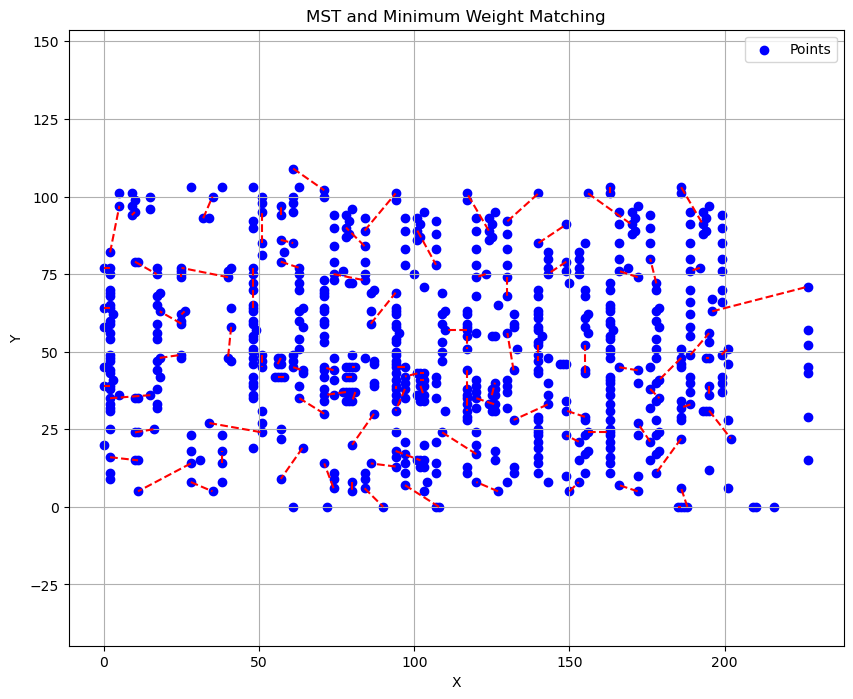

In [104]:
plot_mst_and_matching(points, mstgraph, matching)

In [105]:
len( odd_rows)

200